# Example Calculation

This example demonstrates how the reliability and decision model can be run using the functions provided in `Functions.py`.

The function `run_DT_failure_model` calculates the probability of bridge failure due to scour and produces the figure shown in the paper (Figure 11). The function also returns several values that can be used to compute the Value of Information.

## Running the Model

The following code runs the reliability and decision model using the example dataset `WaterLevel_30Years.csv`. The parameters define the bridge geometry, hydraulic thresholds, and uncertainty in the capacity model.

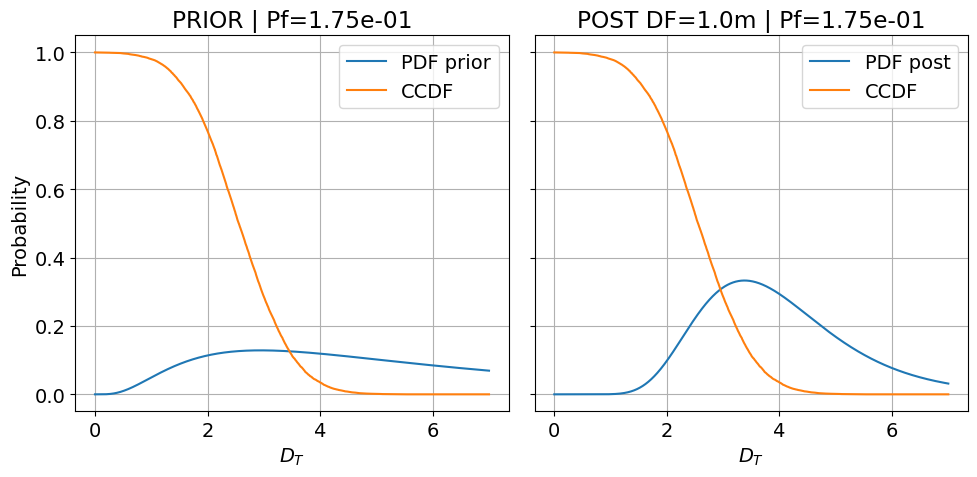

In [2]:
%load_ext autoreload
%autoreload 2

from Functions import *
import pandas as pd

DF_known=1

r, Pf_prior, E_Pf_post, P_fail_post, DF_list = run_DT_failure_model(
    waterlevel_file="WaterLevel_30Years.csv",
    y0=1.0,
    y200 = 2.5,
    Wp=2,
    f_PS=1,
    f_PA=1,
    f_d=1,
    bias=1.0,
    sigma_DT_error=0.3,
    mu= 4,
    sigma=1.38,
    DF_known=DF_known,
    DFmedian=1.349,
    sigma_ln_DF=0.703
)

## Model Output

The figure above shows the probability distributions used in the reliability analysis.

**Left panel – Prior case**

- The blue curve represents the **prior probability density function (PDF)** of the capacity \(D_T\).
- The orange curve shows the **complementary cumulative distribution function (CCDF)**, which represents the probability that the demand exceeds the capacity.
- The resulting **prior probability of failure** is $P_f = 1.75 \times 10^{-1}$.

**Right panel – Posterior case**

- The foundation depth is assumed to be **known** (in this example \(D_F = 1.0\) m).
- The blue curve now represents the **posterior distribution** conditioned on this information.
- The CCDF again represents the exceedance probability used to compute the **posterior probability of failure**.

This comparison illustrates how knowledge of the true foundation depth influences the reliability estimate and forms the basis for the **Value of Information (VoI) calculation**.

## Printing Key Results

The following code prints the calculated results from the model, including:

- Prior probability of failure
- Posterior probabilities of failure
- Expected utilities (costs)
- Value of Information

In [5]:
items = list(r.items())

print("Prior")
print("-" * 30)
for k, v in items[:7]:
    print(f"{k:<22} : {v:.5f}" if isinstance(v, float) else f"{k:<22} : {v}")

print("\nPosterior")
print("-" * 30)
for k, v in items[7:12]:
    print(f"{k:<22} : {v:.5f}" if isinstance(v, float) else f"{k:<22} : {v}")

print("\nVoI")
print("-" * 30)

# second last item (normal formatting)
k, v = items[12]
print(f"{k:<22} : {v:.5f}" if isinstance(v, float) else f"{k:<22} : {v}")

# last item (0 decimal places)
k, v = items[13]
print(f"{k:<22} : {v:.0f}" if isinstance(v, float) else f"{k:<22} : {v}")

Prior
------------------------------
Pf_prior               : 0.17459
pi_great               : 0.02528
pi_low                 : 0.97791
EC_M                   : 0.43584
EC_DN_prior            : 0.43647
EC_RR_prior            : 0.02000
EC_prior               : 0.02000

Posterior
------------------------------
Expected_Pf_Post       : 0.17446
EC_pp                  : 0.01405
Number of optimal DN   : 7267
Number of optimal M    : 0
Number of optimal RR   : 12733

VoI
------------------------------
VoI                    : 0.00595
VoI £                  : 12000
